# Cambiando la frecuencia temporal de los rendimientos

## Caso Amazon

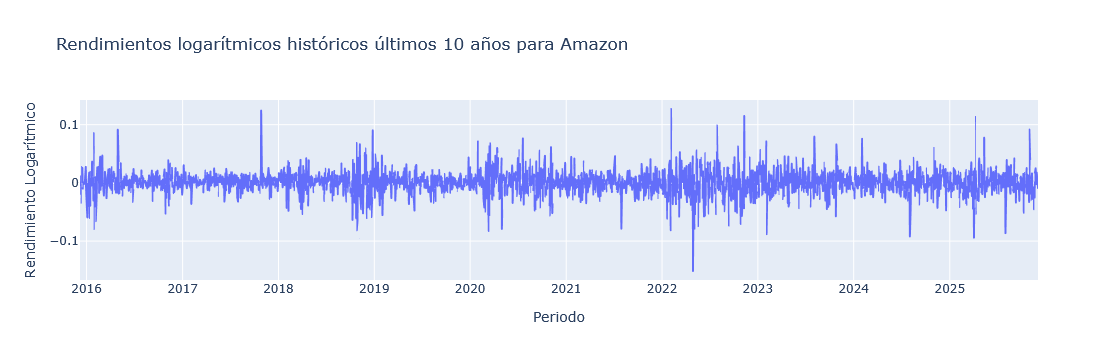

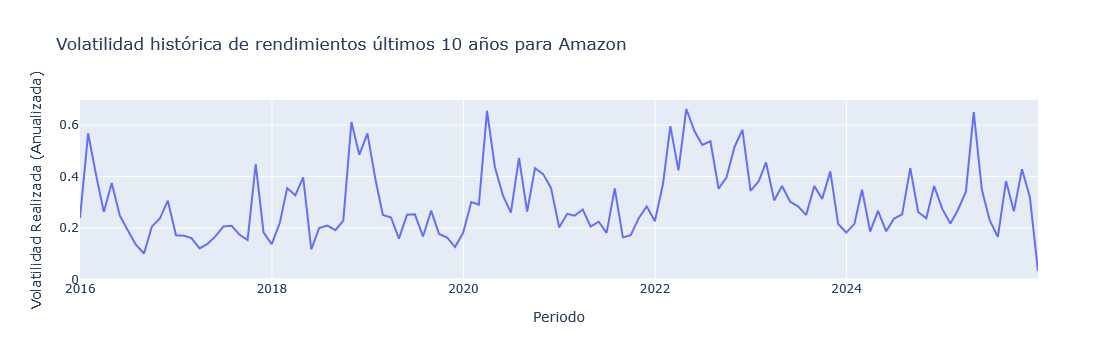

In [19]:
#1.Importar las librerías requeridas

import pandas as pd 
import yfinance as yf
import numpy as np
import warnings
from datetime import datetime
from dateutil.relativedelta import relativedelta
#2. Variables de fechas
fecha_incial = datetime.now()- relativedelta(years=10)
fecha_fin   = datetime.now()

#2. Descargar los datos desdes Yahoo Finance 

df = yf.download('AMZN', 
                 start=fecha_incial.strftime('%Y-%m-%d'),
                 end=fecha_fin.strftime('%Y-%m-%d'),
                 auto_adjust=False,
                 progress=False)

# 3.Guardar solamente el precio de cierre ajustado

df = df.loc[:, ['Adj Close']]
df.rename(columns={'Adj Close': 'adj_close'}, inplace=True)

# 4.Calcular los rendimientos logarítmicos

df['log_rtn'] = np.log(df.adj_close/df.adj_close.shift(1))

#5. Eliminar datos redundantes

df.drop('adj_close', axis=1, inplace=True)
df.dropna(axis=0, inplace=True)


#6 Definir la función para calcular la volatilidad realizada


def realized_volatility(x):
    return np.sqrt(np.sum(x**2))

# 7.Calcular la volatilidad realizada mensual


df_rv = df.groupby(pd.Grouper(freq='M')).apply(realized_volatility)
df_rv.rename(columns={'log_rtn': 'rv'}, inplace=True)


#8. Anualizar los valores

df_rv.rv = df_rv.rv * np.sqrt(12)

# 11.Graficar los resultados

import plotly.express as px
# Gráfico Interactivo para Rendimientos Logarítmicos
fig_rtn = px.line(
    df,
    x=df.index,
    y='log_rtn',
    title='Rendimientos logarítmicos históricos últimos 10 años para Amazon',
    labels={'log_rtn': 'Rendimiento Logarítmico',  'Date': 'Periodo'}
)
fig_rtn.update_traces(hovertemplate='%{y:.4f}<extra></extra>') # Formato del tooltip
fig_rtn.show()

# Gráfico Interactivo para Volatilidad Realizada Mensual
fig_rv = px.line(
    df_rv,
    x=df_rv.index,
    y='rv',
    title='Volatilidad histórica de rendimientos últimos 10 años para Amazon',
    labels={'rv': 'Volatilidad Realizada (Anualizada)', 'Date': 'Periodo'}
)
fig_rv.update_traces(hovertemplate='%{y:.4f}<extra></extra>') # Formato del tooltip
fig_rv.show()